In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rafayel404","key":"86bf30f360a5252916f72eabaafcb5ff"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d gowtamsingulur/rvlcdip

Dataset URL: https://www.kaggle.com/datasets/gowtamsingulur/rvlcdip
License(s): CC0-1.0
100% 4.34G/4.34G [03:44<00:00, 20.7MB/s]



In [4]:
!unzip rvlcdip.zip -d /content/rvlcdip

Streaming output truncated to the last 5000 lines.
  inflating: /content/rvlcdip/data_final/imagesx/x/j/f/xjf38e00/1003080851.tif  
  inflating: /content/rvlcdip/data_final/imagesx/x/j/g/xjg09d00/50434737-4738.tif  
  inflating: /content/rvlcdip/data_final/imagesx/x/j/g/xjg47c00/2082461891_1894.tif  
  inflating: /content/rvlcdip/data_final/imagesx/x/j/g/xjg64e00/1001764469_1001764471.tif  
  inflating: /content/rvlcdip/data_final/imagesx/x/j/g/xjg80d00/517546706+-6707.tif  
  inflating: /content/rvlcdip/data_final/imagesx/x/j/h/xjh09d00/50436353-6353.tif  
  inflating: /content/rvlcdip/data_final/imagesx/x/j/h/xjh28c00/507173521+-3522.tif  
  inflating: /content/rvlcdip/data_final/imagesx/x/j/h/xjh66d00/508560943+-0943.tif  
  inflating: /content/rvlcdip/data_final/imagesx/x/j/i/xji52d00/2021354149.tif  
  inflating: /content/rvlcdip/data_final/imagesx/x/j/j/xjj15c00/2084564898.tif  
  inflating: /content/rvlcdip/data_final/imagesx/x/j/k/xjk09e00/2054608885.tif  
  inflating: /content

In [9]:
import pandas as pd
df=pd.read_csv('/content/rvlcdip/labels_final.csv')
df

,path,label
0,imagesv/v/o/h/voh71d00/509132755+-2755.tif,3
1,imagesl/l/x/t/lxt19d00/502213303.tif,3
2,imagesx/x/e/d/xed05a00/2075325674.tif,2
3,imageso/o/j/b/ojb60d00/517511301+-1301.tif,3
4,imagesq/q/z/k/qzk17e00/2031320195.tif,7
...,...,...
47995,imagesk/k/q/l/kql82f00/tob07414.87.tif,10
47996,imagesi/i/r/r/irr80c00/2084343690_3692.tif,12
47997,imagesa/a/z/h/azh32d00/2063887153_7176.tif,6
47998,imagesg/g/p/d/gpd45f00/0060075263.tif,8


In [10]:
df.shape

(48000, 2)

In [12]:
import pandas as pd

df = pd.read_csv("/content/rvlcdip/labels_final.csv")

base_path = "/content/rvlcdip/data_final/"

df["path"] = base_path + df["path"]

df.head()

,path,label
0,/content/rvlcdip/data_final/imagesv/v/o/h/voh7...,3
1,/content/rvlcdip/data_final/imagesl/l/x/t/lxt1...,3
2,/content/rvlcdip/data_final/imagesx/x/e/d/xed0...,2
3,/content/rvlcdip/data_final/imageso/o/j/b/ojb6...,3
4,/content/rvlcdip/data_final/imagesq/q/z/k/qzk1...,7


(np.float64(-0.5), np.float64(753.5), np.float64(999.5), np.float64(-0.5))

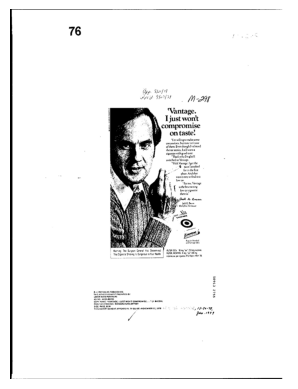

In [18]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(df.loc[0, "path"])

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

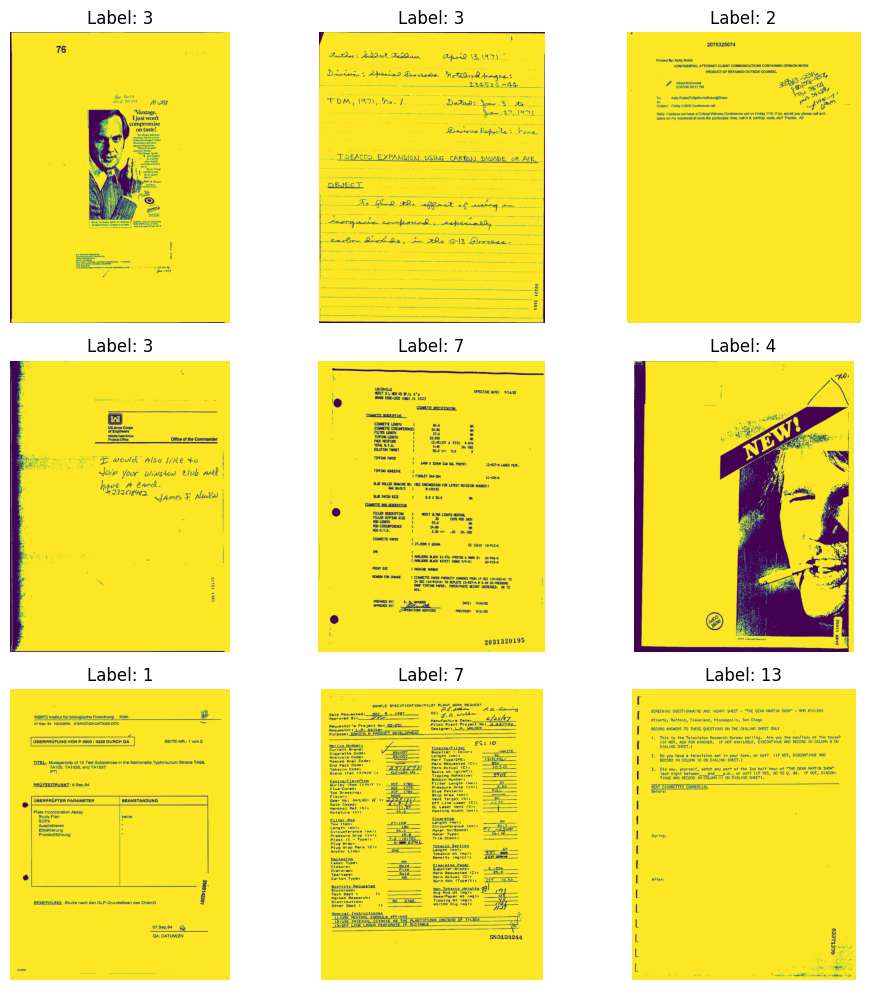

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

# Number of images to display
n = 9

plt.figure(figsize=(10, 10))

for i in range(n):
    img = Image.open(df.loc[i, "path"])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Label: {df.loc[i, 'label']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

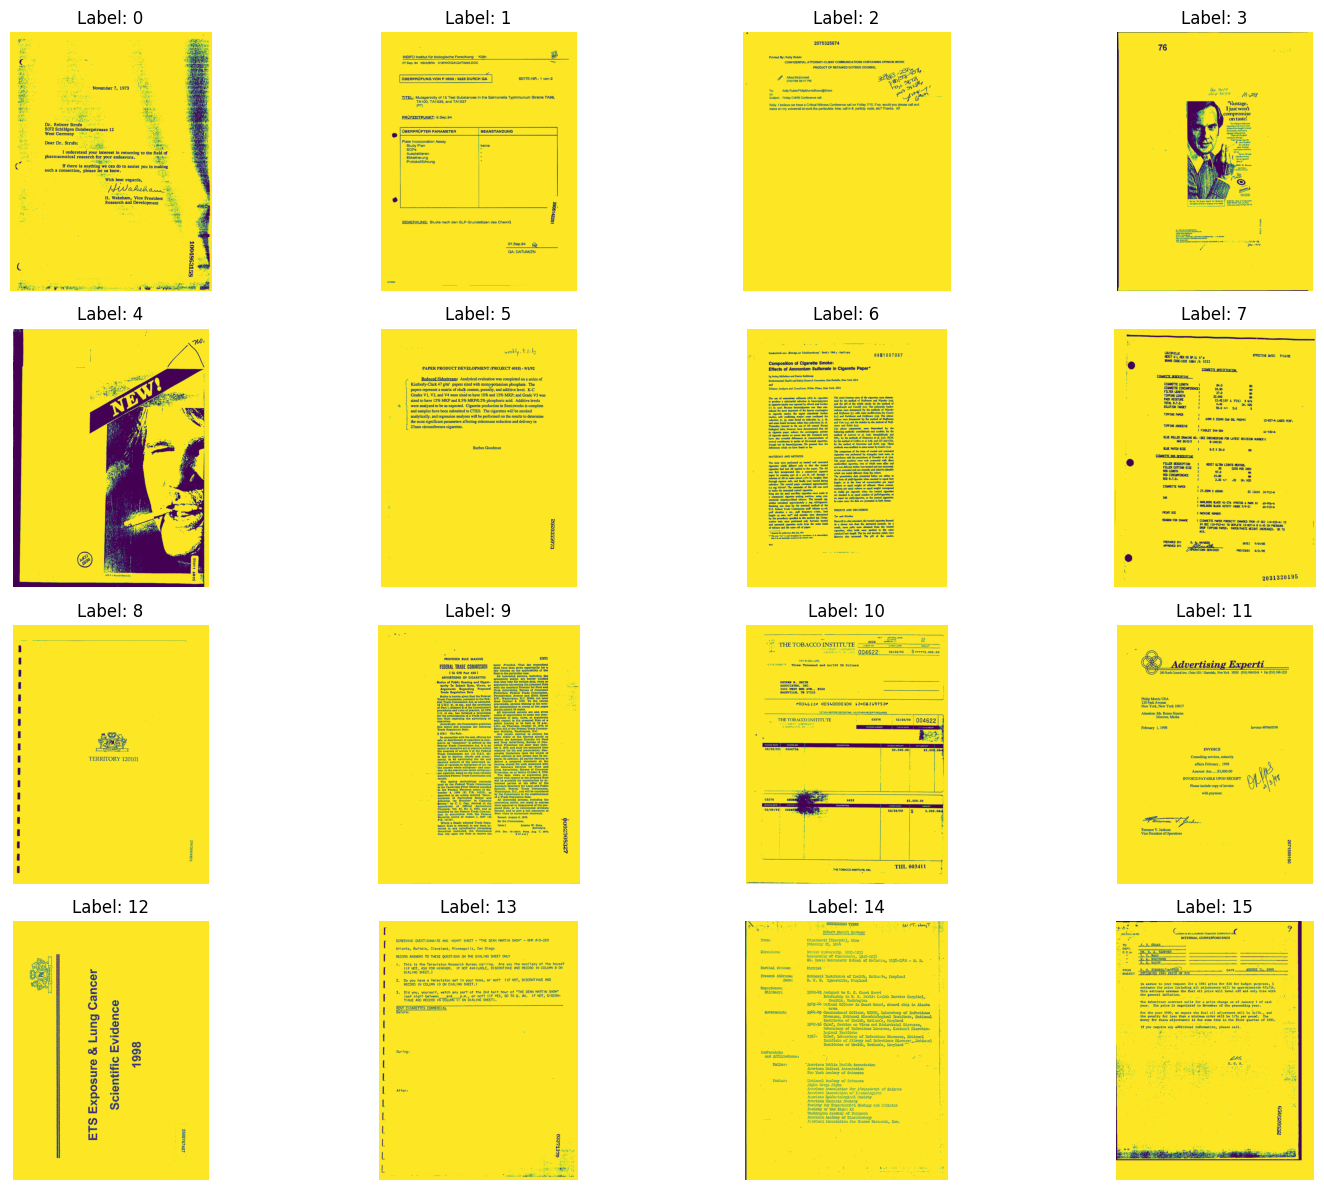

In [20]:
from PIL import Image
import matplotlib.pyplot as plt

labels = sorted(df["label"].unique())

plt.figure(figsize=(16, 12))

for i, label in enumerate(labels):
    # Get the first image of this label
    row = df[df["label"] == label].iloc[0]

    # Open image
    img = Image.open(row["path"])

    # Display
    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
img = Image.open(df.loc[0, "path"])
print(img.size)

(754, 1000)


In [22]:
print(img.mode) # L means grey scale

L


In [23]:
df["label"].value_counts().sort_index()

,count
label,
0,3016
1,2994
2,2993
3,3005
4,2994
5,2999
6,2985
7,3000
8,3003


In [25]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

train_df, valid_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [27]:
train_df["label"] = train_df["label"].astype(str)
valid_df["label"] = valid_df["label"].astype(str)
test_df["label"] = test_df["label"].astype(str)

In [28]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col="label",
    target_size=(224, 224),
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=32,
    shuffle=True
)

Found 30720 validated image filenames belonging to 16 classes.


In [29]:
valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col="path",
    y_col="label",
    target_size=(224, 224),
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)

Found 7680 validated image filenames belonging to 16 classes.


In [30]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="path",
    y_col="label",
    target_size=(224, 224),
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)

Found 9600 validated image filenames belonging to 16 classes.


In [31]:
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

(32, 224, 224, 1)
(32, 16)


In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation = 'relu', input_shape=(224, 224,1)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation = 'relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation = 'relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(64, activation = 'relu'),
    Dense(16, activation = 'softmax'), # 16 classes probability of all 16 classes.
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,680 (42.64 MB)

 Trainable params: 11,177,680 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

# Early stopping

In [34]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',      # Watch validation loss
    patience=3,              # Wait 3 epochs
    restore_best_weights=True
)

# Middle check point

In [35]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True
)

# ReduceLROnPlateau

In [36]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.1,
    patience=2
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

In [37]:
# all in one
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "best_model.keras",
        save_best_only=True,
        monitor="val_loss"
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.1,
        patience=2
    )
]

In [43]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 181s 180ms/step - accuracy: 0.4526 - loss: 1.7577 - val_accuracy: 0.6178 - val_loss: 1.2709 - learning_rate: 0.0010
Epoch 2/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 160s 166ms/step - accuracy: 0.6777 - loss: 1.0597 - val_accuracy: 0.6574 - val_loss: 1.1452 - learning_rate: 0.0010
Epoch 3/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 133s 138ms/step - accuracy: 0.7962 - loss: 0.6653 - val_accuracy: 0.6633 - val_loss: 1.1614 - learning_rate: 0.0010
Epoch 4/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 126s 131ms/step - accuracy: 0.8975 - loss: 0.3293 - val_accuracy: 0.6508 - val_loss: 1.4626 - learning_rate: 0.0010
Epoch 5/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 126s 131ms/step - accuracy: 0.9779 - loss: 0.0829 - val_accuracy: 0.6776 - val_loss: 1.7019 - learning_rate: 1.0000e-04


In [45]:
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

300/300 ━━━━━━━━━━━━━━━━━━━━ 49s 162ms/step - accuracy: 0.6610 - loss: 1.1312
Test Loss: 1.1312
Test Accuracy: 0.6610


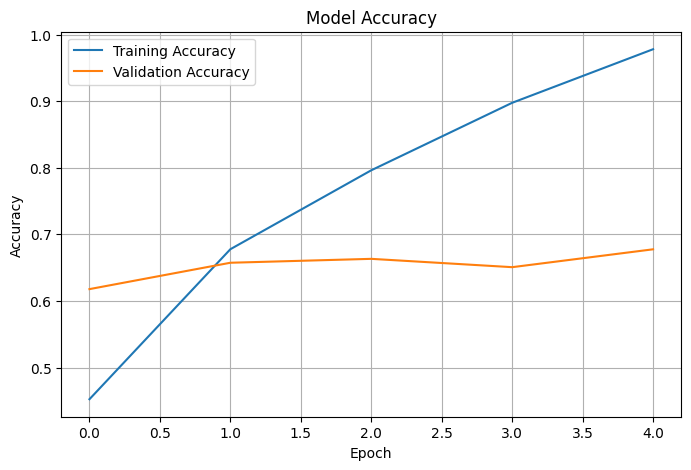

In [46]:
#Plot Training & Validation Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

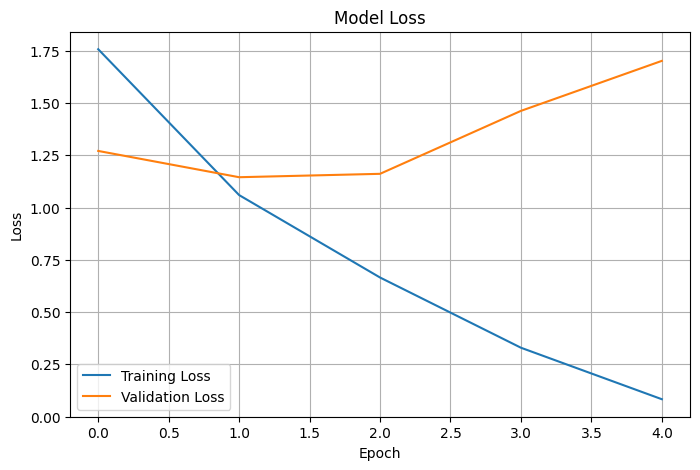

In [47]:
#Plot Training & Validation Loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

300/300 ━━━━━━━━━━━━━━━━━━━━ 39s 126ms/step


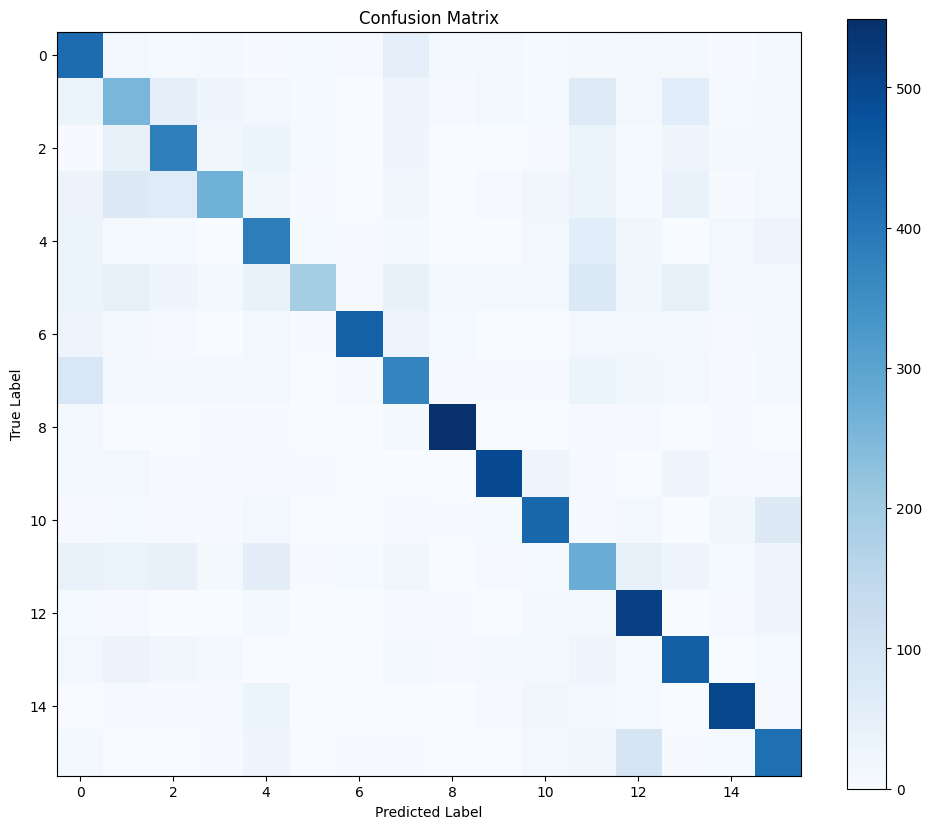

In [48]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

# Predict
pred = model.predict(test_generator)

# Predicted classes
pred_classes = np.argmax(pred, axis=1)

# True classes
true_classes = test_generator.classes

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(12,10))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

In [49]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    pred_classes,
    target_names=list(test_generator.class_indices.keys())
))

              precision    recall  f1-score   support

           0       0.55      0.70      0.62       603
           1       0.45      0.43      0.44       599
          10       0.61      0.63      0.62       600
          11       0.69      0.45      0.54       599
          12       0.59      0.64      0.61       601
          13       0.78      0.32      0.46       601
          14       0.93      0.74      0.82       601
          15       0.60      0.62      0.61       599
           2       0.90      0.92      0.91       599
           3       0.85      0.82      0.83       601
           4       0.73      0.72      0.73       599
           5       0.40      0.46      0.43       600
           6       0.64      0.86      0.73       597
           7       0.63      0.74      0.68       600
           8       0.81      0.83      0.82       601
           9       0.63      0.69      0.66       600

    accuracy                           0.66      9600
   macro avg       0.67   

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step


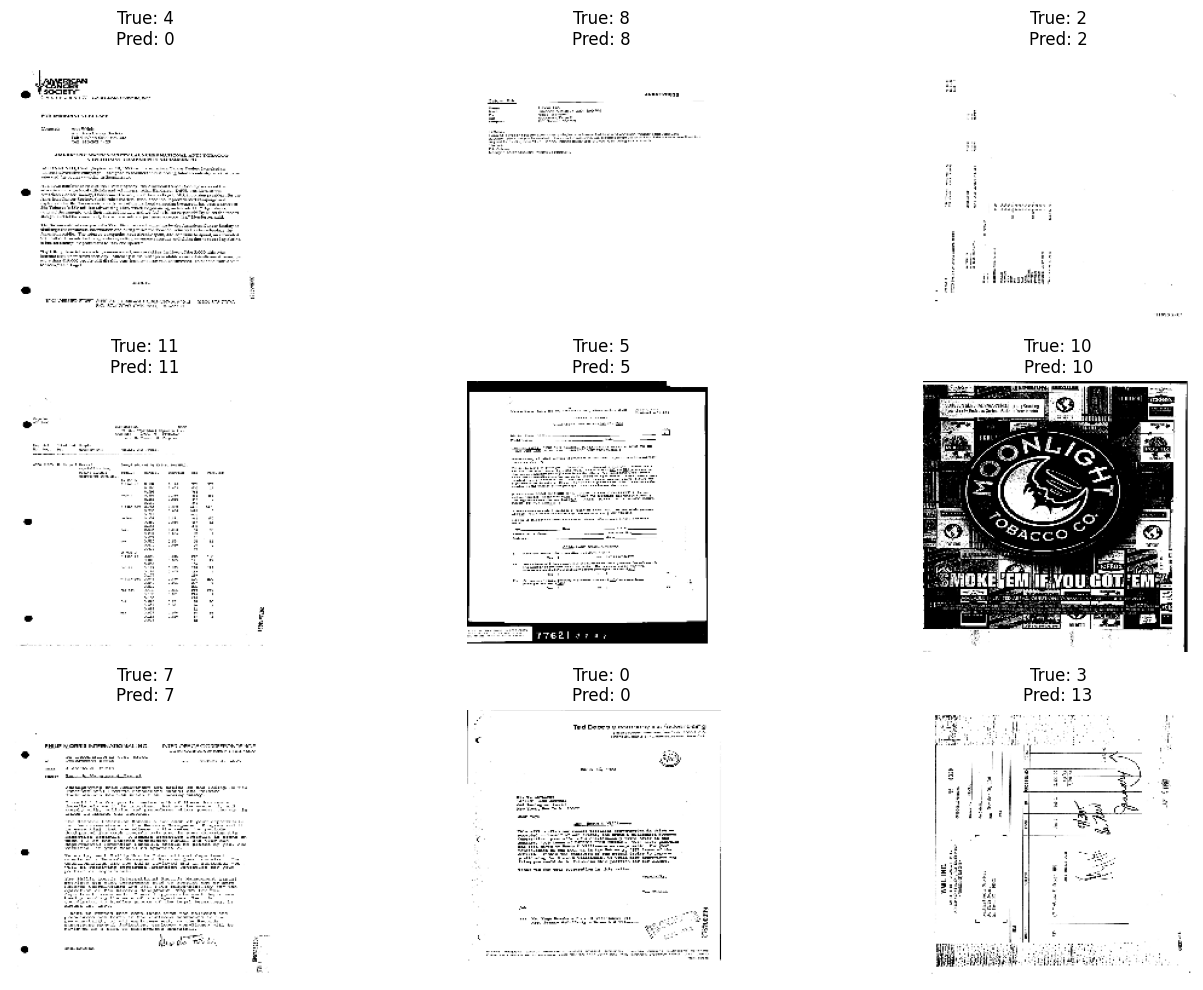

In [50]:
# Visualize Predictions
import numpy as np
import matplotlib.pyplot as plt
images, labels = next(test_generator)

pred = model.predict(images)

pred_labels = np.argmax(pred, axis=1)
true_labels = np.argmax(labels, axis=1)

plt.figure(figsize=(15,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"True: {true_labels[i]}\nPred: {pred_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()